Requirements

In [ ]:
!pip install imbalanced-learn

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


Load the data

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


# Fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# Data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# Combine features and target into a single DataFrame
df = pd.concat([X, y], axis=1)
df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,45,0,0,0,0,1,1,...,0,3,0,5,0,1,5,6,7,0
253676,1,1,1,18,0,0,0,0,0,0,...,0,4,0,0,1,0,11,2,4,1
253677,0,0,1,28,0,0,0,1,1,0,...,0,1,0,0,0,0,2,5,2,0
253678,1,0,1,23,0,0,0,0,1,1,...,0,3,0,0,0,1,7,5,1,0


Scaling continous features **no scaling Age

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Features to scale (excluding the specified list)
features_to_scale = [col for col in df.columns if col not in ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'GenHlth', 'Education', 'Income', 'Diabetes_binary','Age']]

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the selected features
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Display the updated DataFrame
df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,0.325581,1,0,0,0,0,1,...,0,5,0.6,0.500000,1,0,9,4,3,0
1,0,0,0,0.151163,1,0,0,1,0,0,...,1,3,0.0,0.000000,0,0,7,6,1,0
2,1,1,1,0.186047,0,0,0,0,1,0,...,1,5,1.0,1.000000,1,0,9,4,8,0
3,1,0,1,0.174419,0,0,0,1,1,1,...,0,2,0.0,0.000000,0,0,11,3,6,0
4,1,1,1,0.139535,0,0,0,1,1,1,...,0,2,0.1,0.000000,0,0,11,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,0.383721,0,0,0,0,1,1,...,0,3,0.0,0.166667,0,1,5,6,7,0
253676,1,1,1,0.069767,0,0,0,0,0,0,...,0,4,0.0,0.000000,1,0,11,2,4,1
253677,0,0,1,0.186047,0,0,0,1,1,0,...,0,1,0.0,0.000000,0,0,2,5,2,0
253678,1,0,1,0.127907,0,0,0,0,1,1,...,0,3,0.0,0.000000,0,1,7,5,1,0


# Separating the features into medical and lifestyle groups.

In [ ]:
medical_features = ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke',
                    'HeartDiseaseorAttack', 'Sex', 'Age']

lifestyle_features = ['Smoker', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                      'HvyAlcoholConsump', 'NoDocbcCost', 'AnyHealthcare', 'GenHlth',
                      'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
target = 'Diabetes_binary'

XGBoost


=== Grid Search & Feature Importance: Medical Features ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:57:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



 Best Parameters:
{'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200}

 Best F1 Score:
0.413359405602051

 Feature Importances (Gain):
HighBP                  4149.589355
HighChol                 862.353699
HeartDiseaseorAttack     620.065369
Age                      363.928650
BMI                      337.179016
CholCheck                256.113617
Stroke                   164.206100
Sex                       86.290520


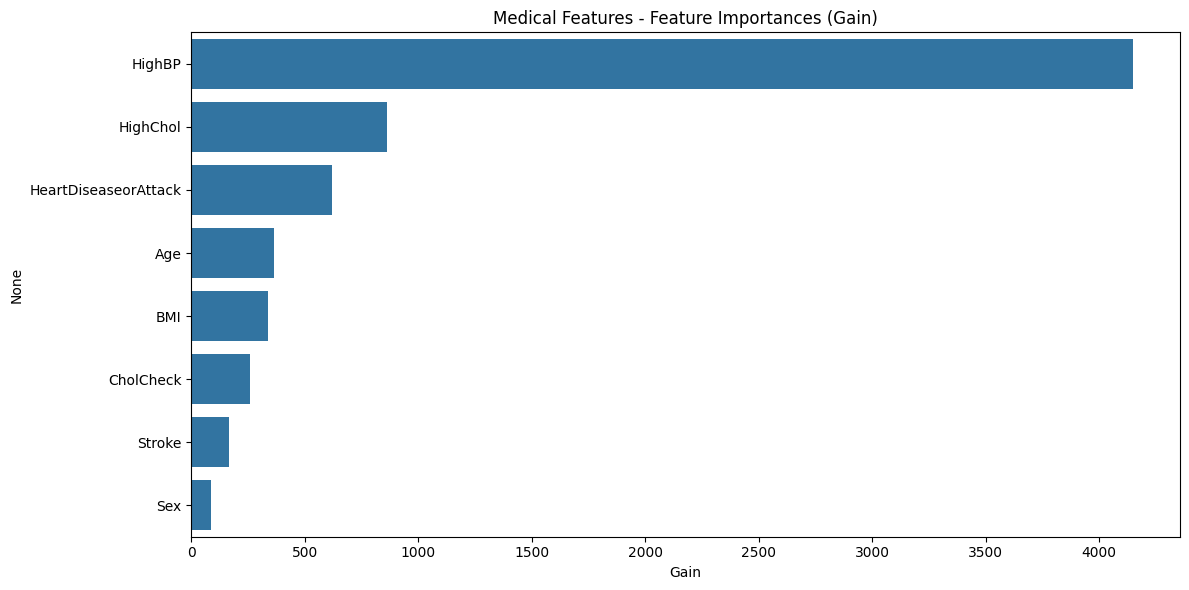


=== Grid Search & Feature Importance: Lifestyle Features ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:03:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



 Best Parameters:
{'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}

 Best F1 Score:
0.40219060290257574

 Feature Importances (Gain):
GenHlth                 3442.427490
Age                     1532.731201
HvyAlcoholConsump       1339.472656
PhysHlth                1327.909546
PhysActivity            1066.796753
MentHlth                1012.123169
Income                   864.529663
Education                533.091187
NoDocbcCost              495.382019
Fruits                   433.131805
HeartDiseaseorAttack     343.254272
Sex                      328.133667
Veggies                  160.477234
DiffWalk                 142.584412
Smoker                    98.608681


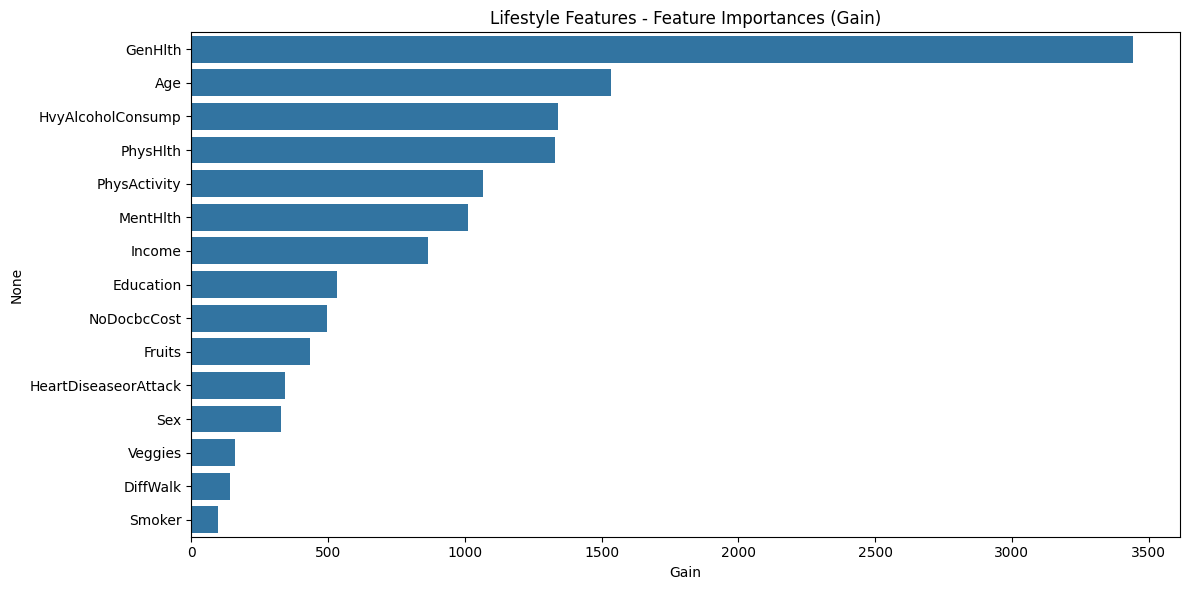

In [ ]:
feature_groups = {
    "Medical Features": medical_features,
    "Lifestyle Features": lifestyle_features
}

y = df['Diabetes_binary']

# Parameter range definition
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.01, 0.1]
}

# Cross validation definition
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)


for group_name, features in feature_groups.items():
    print(f"\n=== Grid Search & Feature Importance: {group_name} ===")

    X = df[features]

    # Pipeline: SMOTE + XGBoost
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('xgb', XGBClassifier(
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        ))
    ])

    # GridSearchCV
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scorer,
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    # Fit
    grid.fit(X, y)

    # Best model
    print("\n Best Parameters:")
    print(grid.best_params_)
    print("\n Best F1 Score:")
    print(grid.best_score_)

    best_model = grid.best_estimator_
    xgb_final = best_model.named_steps['xgb']
    booster = xgb_final.get_booster()
    importance_dict = booster.get_score(importance_type='gain')

    # Mapping feature names
    if all(k.startswith('f') and k[1:].isdigit() for k in importance_dict.keys()):
        mapped_importance = {
            features[int(k[1:])]: v for k, v in importance_dict.items()
        }
    else:
        mapped_importance = importance_dict

    importance_series = pd.Series(mapped_importance).sort_values(ascending=False)

    print("\n Feature Importances (Gain):")
    print(importance_series.to_string())

    plt.figure(figsize=(12, 6))
    sns.barplot(x=importance_series.values, y=importance_series.index)
    plt.title(f"{group_name} - Feature Importances (Gain)")
    plt.xlabel("Gain")
    plt.tight_layout()
    plt.show()


Random Forest


Running GridSearchCV for: Medical Features
Fitting 3 folds for each of 2 candidates, totalling 6 fits

Best Parameters for Medical:
{'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best F1 Score: 0.4128

Feature Importances:
HighBP                  0.309452
BMI                     0.266458
HighChol                0.162788
Age                     0.147712
HeartDiseaseorAttack    0.074117
CholCheck               0.016352
Stroke                  0.014504
Sex                     0.008619
dtype: float64


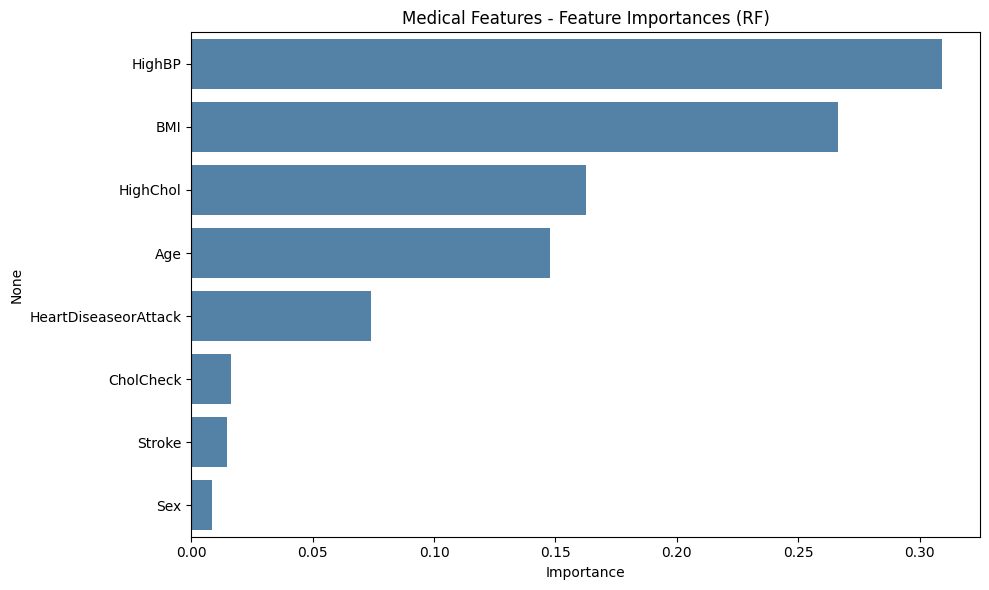


Running GridSearchCV for: Lifestyle Features
Fitting 3 folds for each of 2 candidates, totalling 6 fits

Best Parameters for Lifestyle:
{'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best F1 Score: 0.3994

Feature Importances:
GenHlth                 0.337450
Age                     0.189582
PhysHlth                0.189308
DiffWalk                0.050080
Income                  0.049116
MentHlth                0.047238
HvyAlcoholConsump       0.045615
Education               0.025160
PhysActivity            0.020887
HeartDiseaseorAttack    0.012854
Sex                     0.010613
NoDocbcCost             0.009881
Fruits                  0.004700
Veggies                 0.003505
Smoker                  0.002717
AnyHealthcare           0.001297
dtype: float64


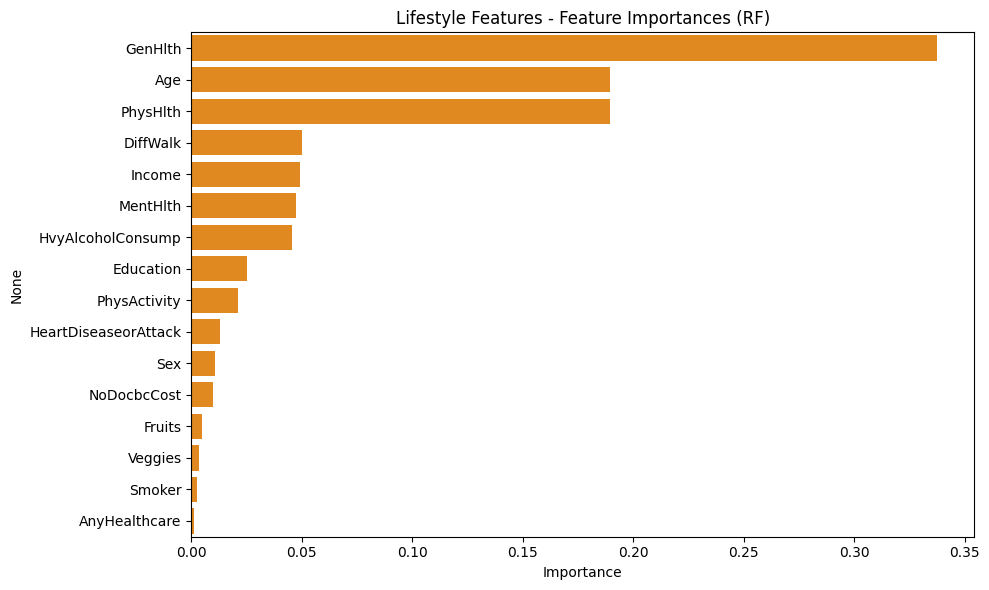

In [ ]:
# Optimized parameter grid
param_grid = {
    'rf__n_estimators': [100],
    'rf__max_depth': [10, 20],
    'rf__min_samples_split': [2],
    'rf__min_samples_leaf': [1],
    'rf__max_features': ['sqrt']
}

# Cross-validation and scoring
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

# Pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Feature groups
feature_groups = {
    "Medical": medical_features,
    "Lifestyle": lifestyle_features
}

# Grid search and plotting
for group_name, features in feature_groups.items():
    print(f"\nRunning GridSearchCV for: {group_name} Features")
    X = df[features]
    y = df[target]

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scorer,
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X, y)

    best_rf = grid.best_estimator_.named_steps['rf']
    importances = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)

    print(f"\nBest Parameters for {group_name}:")
    print(grid.best_params_)
    print(f"Best F1 Score: {grid.best_score_:.4f}")
    print("\nFeature Importances:")
    print(importances)

    # Plot feature importances separately
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.values, y=importances.index, color='steelblue' if group_name == 'Medical' else 'darkorange')
    plt.title(f"{group_name} Features - Feature Importances (RF)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
